# The three core ideas for this phase are

1. The "Task Fingerprint" Model: Can we identify the type of experiment (Aiming, Prehension, Illusions) a trial came from, based only on its kinematic signature?

2. Nested Analysis of "Messy" Aiming Clusters: Can we uncover the hidden structure in the Aiming data by testing the hypothesis that visual condition (visCond) influences movement strategy?

3. Formal Anomaly Detection: Can we formally identify and characterize the "outlier" movements in the Visual Illusions dataset?


## Step 1.1: Data Aggregation and Feature Harmonization

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import GroupKFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA

In [2]:
df_prehension = pd.read_csv("../../data/02_processed/prehension_master_dataset.csv")
df_aiming = pd.read_csv("../../data/02_processed/aiming_master_dataset.csv")
df_illusions = pd.read_csv("../../data/02_processed/visual_illusions_master_dataset.csv")


In [3]:
# Add a 'task_type' column to each before combining
df_prehension['task_type'] = 'prehension'
df_aiming['task_type'] = 'aiming'
df_illusions['task_type'] = 'illusion'

# Identify common columns
common_cols = list(set(df_prehension.columns) & set(df_aiming.columns) & set(df_illusions.columns))


In [4]:
if 'task_type' not in common_cols: common_cols.append('task_type')
if 'subjName' not in common_cols: common_cols.append('subjName')
    
print(f"Found {len(common_cols)} common columns across all datasets.")


Found 163 common columns across all datasets.


In [5]:
# Concatenate the dataframes using only common columns
df_combined = pd.concat([
    df_prehension[common_cols],
    df_aiming[common_cols],
    df_illusions[common_cols]
], ignore_index=True)

print(f"Combined dataset shape: {df_combined.shape}")

# Define features: all common numeric columns except identifiers
features_combined = df_combined.select_dtypes(include=np.number).columns.tolist()
identifiers = ['subjName', 'trialN'] 
features_combined = [col for col in features_combined if col not in identifiers]

print(f"Using {len(features_combined)} common kinematic features for the model.")


Combined dataset shape: (6857, 163)
Using 159 common kinematic features for the model.


## Step 1.2: Build and Evaluate the Multi-Class Classifier

In [6]:
# Prepare data for the Task Fingerprint model
X = df_combined[features_combined]
y = df_combined['task_type']
groups = df_combined['subjName'] 

# Encode the target variable
le_task = LabelEncoder()
y_encoded = le_task.fit_transform(y)
task_label_map = {i: label for i, label in enumerate(le_task.classes_)}
print(f"Task label mapping: {task_label_map}")


Task label mapping: {0: 'aiming', 1: 'illusion', 2: 'prehension'}


In [7]:
pipeline_task = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss'))
])


In [8]:
try:
    group_kfold = GroupKFold(n_splits=5)
    cv_scores_task = cross_val_score(pipeline_task, X, y_encoded, cv=group_kfold, groups=groups)
    print("Using GroupKFold for cross-validation.")
except ValueError:
    print("Warning: Subjects might not be shared across tasks. Falling back to Stratified K-Fold.")
    from sklearn.model_selection import StratifiedKFold
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores_task = cross_val_score(pipeline_task, X, y_encoded, cv=skf)

print(f"\nTask Fingerprint CV Accuracy Scores: {cv_scores_task}")
print(f"Mean CV Accuracy: {np.mean(cv_scores_task):.4f} (+/- {np.std(cv_scores_task):.4f})")

# Fit the final model to get feature importances
print("\nFitting final model on all data to get feature importances...")
pipeline_task.fit(X, y_encoded)


c:\CourseWork\Classifying_grip_strategies_ml\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:28:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\CourseWork\Classifying_grip_strategies_ml\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:28:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\CourseWork\Classifying_grip_strategies_ml\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:28:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\CourseWork\Classifying_grip_strategies_ml\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:28:52] WARNING: C:\actions-runner\_work\

Using GroupKFold for cross-validation.

Task Fingerprint CV Accuracy Scores: [0.99773243 0.99924471 1.         0.99929627 0.99852833]
Mean CV Accuracy: 0.9990 (+/- 0.0008)

Fitting final model on all data to get feature importances...


c:\CourseWork\Classifying_grip_strategies_ml\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:28:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None


## Step 1.3: Interpret the "Task Fingerprint"

C:\Users\bharg\AppData\Local\Temp\ipykernel_23192\2855618631.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df_task.head(20), palette='viridis')


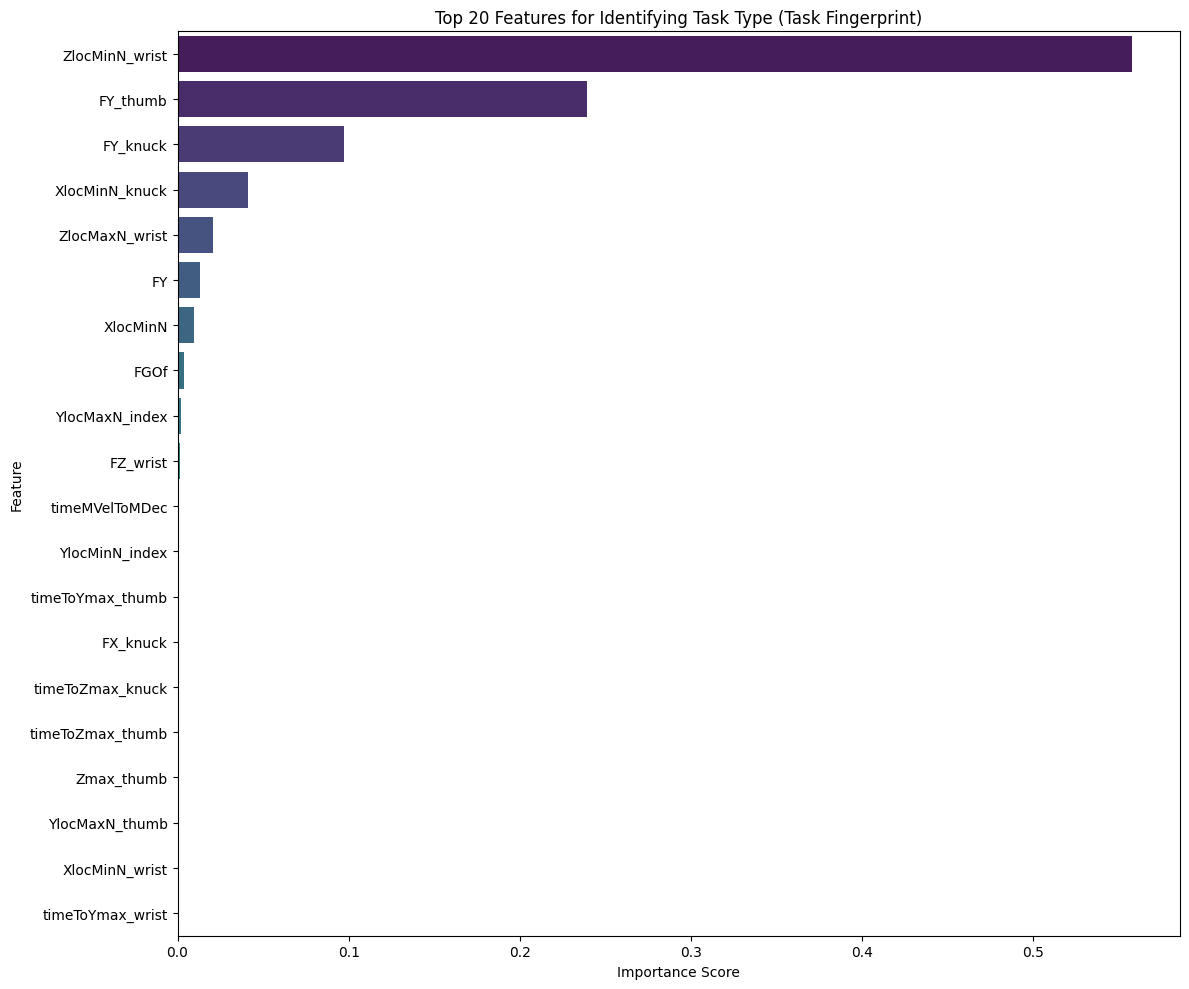


Top 10 most important features for distinguishing tasks:
            feature  importance
81   ZlocMinN_wrist    0.557735
97         FY_thumb    0.239446
152        FY_knuck    0.097402
138  XlocMinN_knuck    0.041457
82   ZlocMaxN_wrist    0.020927
31               FY    0.012884
38         XlocMinN    0.009717
134            FGOf    0.003555
68   YlocMaxN_index    0.002299
10         FZ_wrist    0.001170


In [9]:
importances_task = pipeline_task.named_steps['classifier'].feature_importances_
feature_importance_df_task = pd.DataFrame({
    'feature': features_combined,
    'importance': importances_task
}).sort_values('importance', ascending=False)

# Plot the importances
plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importance_df_task.head(20), palette='viridis')
plt.title('Top 20 Features for Identifying Task Type (Task Fingerprint)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig("../../results/figures/task_fingerprint_feature_importance.png")
plt.show()

print("\nTop 10 most important features for distinguishing tasks:")
print(feature_importance_df_task.head(10))


# Task 2: Nested Analysis of Aiming Clusters

## Step 2.1: Isolate a Subset of Data

In [10]:
# Nested Analysis of Aiming Dataset
print("\n" + "="*50)
print("Nested Analysis of Aiming Dataset")
print("="*50 + "\n")

# Filter for a single distance condition
df_aiming_subset = df_aiming[df_aiming['distance'] == 'two'].copy()
print(f"Subset shape for distance='two': {df_aiming_subset.shape}")

# Use the same full kinematic feature set as before
kinematic_features_aiming = df_aiming.select_dtypes(include=np.number).drop(columns=['subjName', 'trialN']).columns
X_subset = df_aiming_subset[kinematic_features_aiming]


Nested Analysis of Aiming Dataset

Subset shape for distance='two': (805, 214)


In [11]:
# Scale and apply PCA
X_subset_scaled = StandardScaler().fit_transform(X_subset)
# We don't know the optimal number of components, so let's use 95% variance
pca_subset = PCA(n_components=0.95)
X_subset_pca = pca_subset.fit_transform(X_subset_scaled)
print(f"PCA on subset reduced dimensions to {pca_subset.n_components_} components.")


PCA on subset reduced dimensions to 58 components.


## Step 2.2: Re-run Clustering and Analyse the Crosstab

In [12]:
from sklearn.cluster import KMeans

# Perform clustering (let's check for k=2 and k=3)
kmeans_k2 = KMeans(n_clusters=2, random_state=42, n_init='auto')
df_aiming_subset['strategy_k2'] = kmeans_k2.fit_predict(X_subset_pca)

kmeans_k3 = KMeans(n_clusters=3, random_state=42, n_init='auto')
df_aiming_subset['strategy_k3'] = kmeans_k3.fit_predict(X_subset_pca)

# Analyze the relationship between new clusters and vision condition
print("\n--- Crosstab: New Clusters (k=2) vs. Vision Condition ---")
print(pd.crosstab(df_aiming_subset['strategy_k2'], df_aiming_subset['visCond']))

print("\n--- Crosstab: New Clusters (k=3) vs. Vision Condition ---")
print(pd.crosstab(df_aiming_subset['strategy_k3'], df_aiming_subset['visCond']))



--- Crosstab: New Clusters (k=2) vs. Vision Condition ---
visCond      bino  clear  mono
strategy_k2                   
0             146    113   144
1             138    151   113

--- Crosstab: New Clusters (k=3) vs. Vision Condition ---
visCond      bino  clear  mono
strategy_k3                   
0             121     85   113
1              98    101    86
2              65     78    58


# Task 3: Formal Anomaly Detection in Visual Illusions
Objective: Instead of letting outliers form a tiny, unhelpful cluster, we'll use a dedicated algorithm to formally identify and characterize them.


## Step 3.1: Apply Isolation Forest

In [ ]:
from sklearn.ensemble import IsolationForest

def get_curated_features(df, drop_cols=[]):
    leaky_patterns = ['Xmax', 'Ymax', 'Zmax', 'FX', 'FY', 'FZ', 'Xloc', 'Yloc', 'Zloc']
    identifiers = ['subjName', 'trialN']
    
    # Get all numeric columns
    kinematic_features = df.select_dtypes(include=np.number).columns.tolist()
    
    # Remove identifiers and any explicitly dropped columns
    kinematic_features = [col for col in kinematic_features if col not in identifiers and col not in drop_cols]
    
    # Filter out features that start with a leaky pattern
    curated_features = [
        feat for feat in kinematic_features
        if not any(feat.startswith(pattern) for pattern in leaky_patterns)
    ]
    return curated_features

# The rest of your script for anomaly detection would follow...

# Anomaly Detection in Visual Illusions
print("\n" + "="*50)
print("Anomaly Detection in Visual Illusions Dataset")
print("="*50 + "\n")

# Apply the corrected function
illusions_features = get_curated_features(df_illusions, drop_cols=['targetSize'])
X_illusions = df_illusions[illusions_features]

print(f"Using {len(illusions_features)} curated features for anomaly detection.")

X_illusions_scaled = StandardScaler().fit_transform(X_illusions)
pca_illusions = PCA(n_components=0.95)
X_illusions_pca = pca_illusions.fit_transform(X_illusions_scaled)

# Initialize and fit the model
iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
df_illusions['anomaly_label'] = iso_forest.fit_predict(X_illusions_pca)

df_illusions['anomaly_score'] = iso_forest.decision_function(X_illusions_pca)

# Count the detected anomalies
n_anomalies = (df_illusions['anomaly_label'] == -1).sum()
print(f"Detected {n_anomalies} anomalous trials.")



Anomaly Detection in Visual Illusions Dataset

Using 89 curated features for anomaly detection.
Detected 17 anomalous trials.


## Step 3.2: Characterise the Anomalies

In [14]:
# Separate the anomalies from the inliers
anomalies = df_illusions[df_illusions['anomaly_label'] == -1]
inliers = df_illusions[df_illusions['anomaly_label'] == 1]

# Compare the mean of key kinematic features
comparison_features = ['movTime', 'MVel', 'MAcc', 'pathLength', 'MGA']
anomaly_profile = pd.DataFrame({
    'Anomalies': anomalies[comparison_features].mean(),
    'Inliers': inliers[comparison_features].mean()
})

print("\n--- Kinematic Profile: Anomalies vs. Inliers ---")
print(anomaly_profile)

print("\nAnomaly distribution by illusion type:")
print(anomalies['illusion'].value_counts(normalize=True))

print("\nAnomaly distribution by subject:")
print(anomalies['subjName'].value_counts())


--- Kinematic Profile: Anomalies vs. Inliers ---
            Anomalies   Inliers
movTime      1.675686  0.759550
MVel         0.826031  0.771342
MAcc         7.115105  4.753831
pathLength   0.538521  0.312576
MGA          0.101479  0.071732

Anomaly distribution by illusion type:
illusion
Ponzo         0.588235
Ebbinghaus    0.411765
Name: proportion, dtype: float64

Anomaly distribution by subject:
subjName
13    4
6     2
12    2
7     2
5     1
2     1
3     1
9     1
8     1
10    1
20    1
Name: count, dtype: int64
